TO-DO:

STEP 1:
- address and fix all the professors corrections on the report and make changes to the overleaf report and the github repository


STEP 2:
- be able to draw graphs for all the .dot files. Keep in mind that some may give strange/particular drawings.
- it's fine to have very different represetation of the trees with different root nodes, also very different representation between bfs and dfs. However, the decision of the root node may create very different layout representation depending on the .dot file. So, we should address it in the report and comment on why some graphs have very similar layout (eg. League file) and other have very different ones. To do this, we first have to draw all the graphs (see Outpust folder) and take some examples from those photos.
- Things to address in the layered layout:
    - it should have an horizontal dotted lines that mark the depth level of the nodes;
    - we should recreate an accurate level based layout, beacuase the one that we've developed so far won't get us the full mark;
    - we should also draw on the side of the tree the nodes that weren't visited by the BFS/DFS (in another color) and the eventual edges between them;
    - we should add drawings of non-trees edges to the already constructed graph. We could draw them with straight/bended red dotted lines.
- for the quality metrics: from slide_1(introduction), we shoudl address the ones that our layout solution solves (eg. no crossings between edges) and the ones that are still not solved. Moreover, we could think about other QM that our solution may address or that could be a focus of future improvements.


for both step 1 and 2, we should put the option to display/hide the nodes' id


last but not least, the professor encouraged us to not us copilot or any form of AI assistent to write the code


libraries:

In [36]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque

.dot files:

In [37]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/Step1/JazzNetwork.dot" #tree
data_name_2 = "../Dataset/Step1/LesMiserables.dot" #tree
data_name_3 = "../Dataset/OTHERS/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/OTHERS/g.20.27.dot"
data_name_5 = "../Dataset/OTHERS/g.42.88.dot"
data_name_6 = "../Dataset/OTHERS/GD97.dot"
data_name_7 = "../Dataset/OTHERS/LeagueNetwork.dot" #tree
data_name_8 = "../Dataset/OTHERS/mesh graph.dot"
data_name_9 = "../Dataset/OTHERS/noname.dot"
data_name_10 = "../Dataset/OTHERS/polblogs.dot"
data_name_11 = "../Dataset/OTHERS/robot graph.dot"
data_name_12 = "../Dataset/OTHERS/rome.dot" #tree
data_name_13 = "../Dataset/OTHERS/snail graph.dot"

# list of file names
data_list = [data_name_1, data_name_2, data_name_3, data_name_4, data_name_5, data_name_6, data_name_7, data_name_8, data_name_9, data_name_10, data_name_11, data_name_12, data_name_13]

# file name list
data_names = ['JazzNetwork', 'LesMiserables', 'devonshiredebate_withclusters', 'g.20.27', 'g.42.88', 'GD97', 'LeagueNetwork', 'mesh_graph', 'noname', 'polblogs', 'robot_graph', 'rome', 'snail_graph']


defined functions:

In [ ]:
# from dot file to graph object (having adjacency list of nodes)
def parse_dot_file(file_path):
    graph = pydot.graph_from_dot_file(file_path)[0]
    adjacency_list = {}
    
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        if src not in adjacency_list:
            adjacency_list[src] = []
        if dst not in adjacency_list:
            adjacency_list[dst] = []
        adjacency_list[src].append(dst)
        adjacency_list[dst].append(src)  # for undirected graph
    
    return adjacency_list
# create bfs tree
def create_bfs_tree(graph, root):
    visited = set()
    queue = deque([root])
    bfs_tree = {root: []}
    
    while queue:
        node = queue.popleft()
        visited.add(node)
        
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                bfs_tree[node].append(neighbor)
                bfs_tree[neighbor] = []
    
    return bfs_tree
# create dfs tree
def create_dfs_tree(graph, root, visited=None, tree=None):
    if visited is None:
        visited = set()
    if tree is None:
        tree = {root: []}
    
    visited.add(root)
    
    for neighbor in graph.get(root, []):
        if neighbor not in visited:
            tree[root].append(neighbor)
            tree[neighbor] = []
            create_dfs_tree(graph, neighbor, visited, tree)
    
    return tree
# draw the layered tree layout
def draw_layered_tree(tree, title="Layered Tree Layout"):
    levels = {}
    def assign_levels(node, depth=0):
        if node not in levels:
            levels[node] = depth
        for child in tree[node]:
            assign_levels(child, depth + 1)
    assign_levels(next(iter(tree)))
    
    nodes_by_level = {}
    for node, level in levels.items():
        if level not in nodes_by_level:
            nodes_by_level[level] = []
        nodes_by_level[level].append(node)
    
    plt.figure(figsize=(8, 6))
    y_positions = {level: -level for level in nodes_by_level}
    coordinates_positions = {}
    
    for level in nodes_by_level:
        x_spacing = 2 # deve essere regolato in base al numero di nodi nel livello
        start_x = -x_spacing * (len(nodes_by_level[level]) - 1) / 2
        for i, node in enumerate(nodes_by_level[level]):
            coordinates_positions[node] = (start_x + i * x_spacing, y_positions[level]) # da modificare chiamandolo coordinate
    
    for parent, children in tree.items():
        for child in children:
            x1, y1 = coordinates_positions[parent]
            x2, y2 = coordinates_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-')
    
    for node, (x, y) in coordinates_positions.items(): # qui dobbiamo mettere un controllo che permette di fare il print o meno degli id dei nodi
        plt.text(x, y, node, ha='center', va='center', fontsize=12,
                 bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    
    plt.title(title)
    plt.axis('off')
    plt.show()
# save the drawing of the graph to a png file in ../Outputs folder
def save_drawing(tree, title="Layered Tree Layout"):
    levels = {}
    def assign_levels(node, depth=0):
        if node not in levels:
            levels[node] = depth
        for child in tree[node]:
            assign_levels(child, depth + 1)
    assign_levels(next(iter(tree)))
    
    nodes_by_level = {}
    for node, level in levels.items():
        if level not in nodes_by_level:
            nodes_by_level[level] = []
        nodes_by_level[level].append(node)
    
    plt.figure(figsize=(8, 6))
    y_positions = {level: -level for level in nodes_by_level}
    coordinates_positions = {}
    
    for level in nodes_by_level:
        x_spacing = 2 # deve essere regolato in base al numero di nodi nel livello
        start_x = -x_spacing * (len(nodes_by_level[level]) - 1) / 2
        for i, node in enumerate(nodes_by_level[level]):
            coordinates_positions[node] = (start_x + i * x_spacing, y_positions[level]) # da modificare chiamandolo coordinate
    
    for parent, children in tree.items():
        for child in children:
            x1, y1 = coordinates_positions[parent]
            x2, y2 = coordinates_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-')
    
    for node, (x, y) in coordinates_positions.items(): # qui dobbiamo mettere un controllo che permette di fare il print o meno degli id dei nodi
        plt.text(x, y, node, ha='center', va='center', fontsize=12,
                 bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    
    plt.title(title)
    plt.axis('off')
    plt.savefig(title)

Example of bfs/dfs trees:

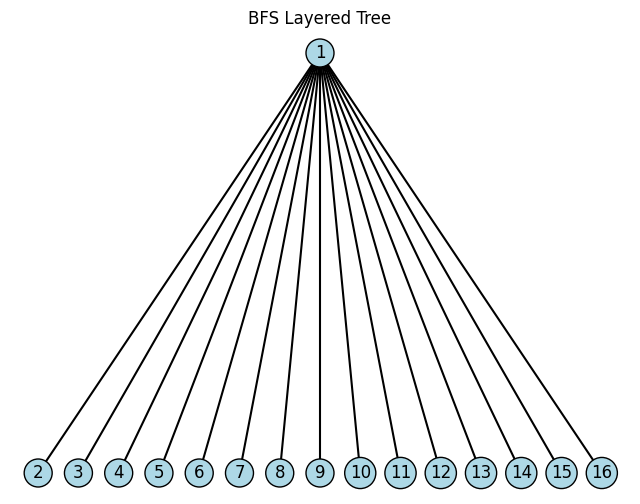

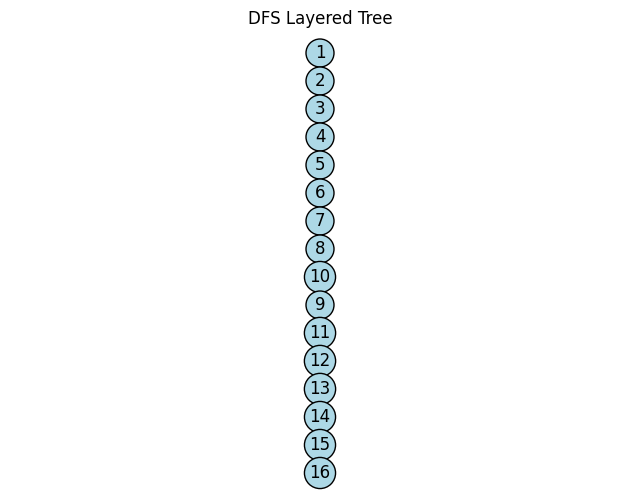

In [30]:
# select the dot file to be used
dot_file = data_name_7
graph = parse_dot_file(dot_file)

# select the root node
root_node = "1"

bfs_result = create_bfs_tree(graph, root_node)
dfs_result = create_dfs_tree(graph, root_node)

draw_layered_tree(bfs_result, "BFS Layered Tree")
draw_layered_tree(dfs_result, "DFS Layered Tree")

Storing all the photos of the trees in the corresponding folders. This way we can go through them and spot similarities and differences:

Folder to store the drawings:

In [34]:
# if not already created by the user, create the output folder with subfolders for each file_name and their bfs and dfs subfolders
import os
if not os.path.exists("../Outputs"):
    os.mkdir("../Outputs")
    for file_name in data_names:
        os.mkdir(f"../Outputs/{file_name}")
        os.mkdir(f"../Outputs/{file_name}/bfs")
        os.mkdir(f"../Outputs/{file_name}/dfs")

else: print("The folder already exists")

Now, we can draw all the possible combinations of dfs and bfs trees: 

this will take a lot of time (like 30 minutes or more)

------ File: JazzNetwork

Node: 1
Saved images of node: 1
Node: 10
Saved images of node: 10
Node: 11
Saved images of node: 11
Node: 12
Saved images of node: 12
Node: 13


KeyboardInterrupt: 

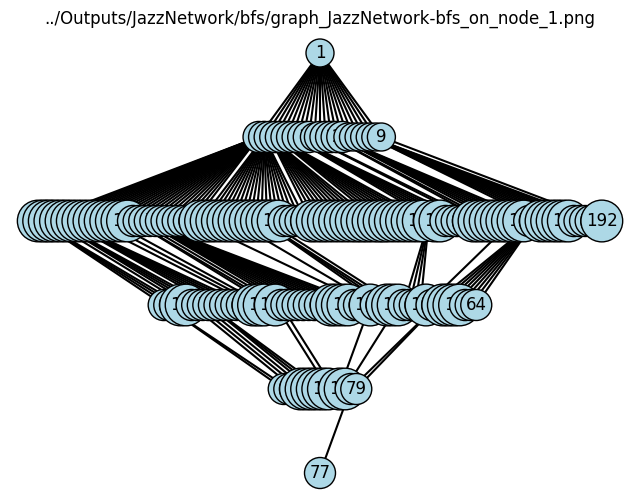

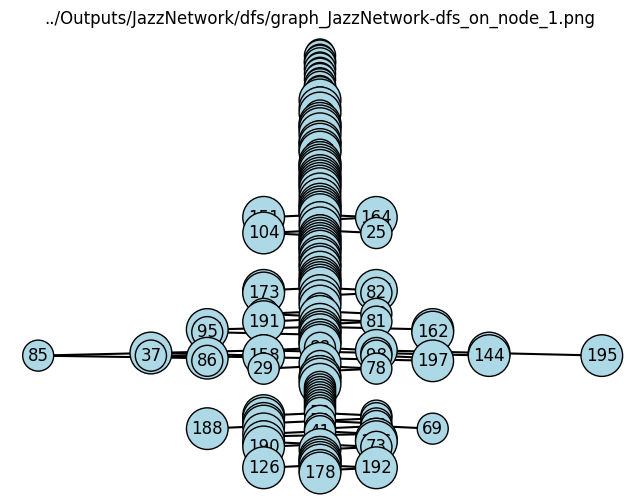

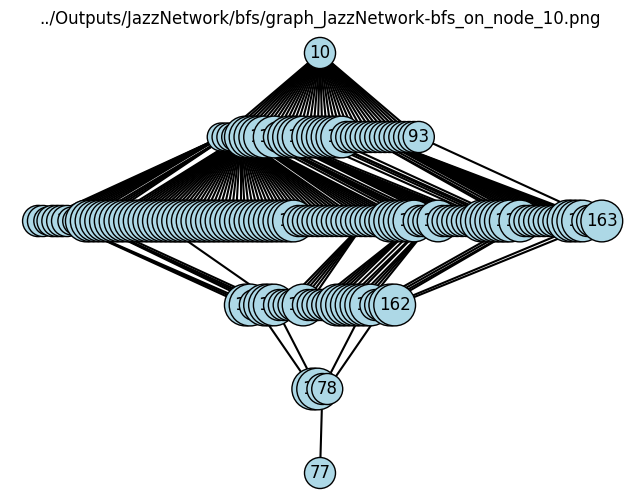

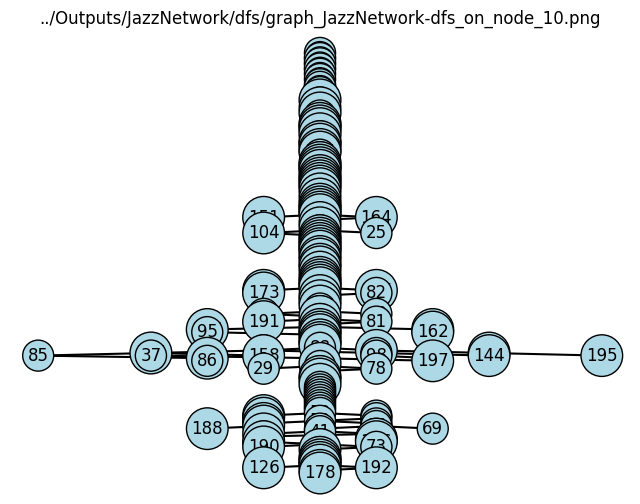

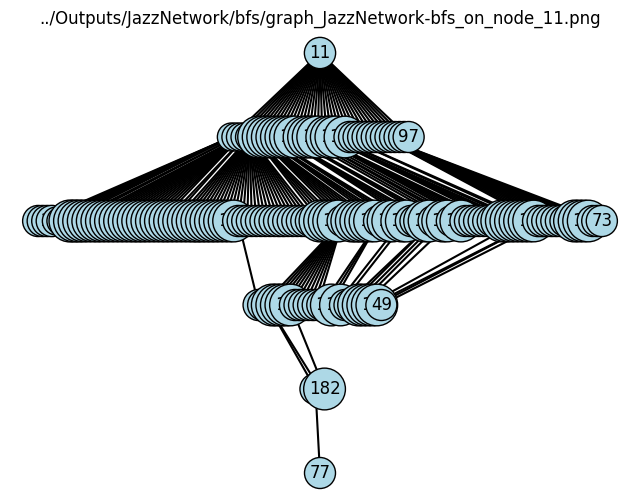

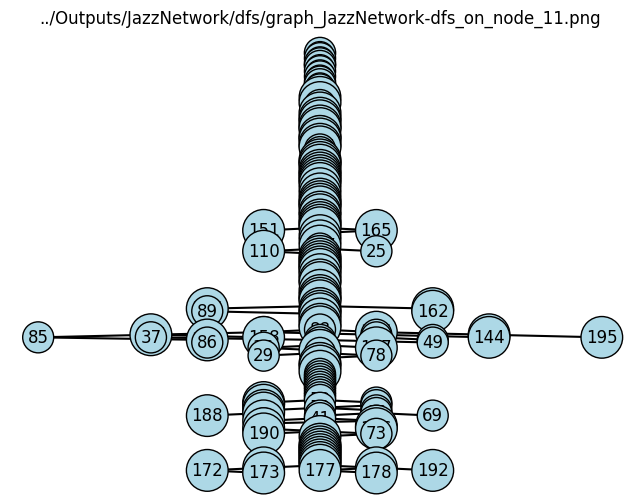

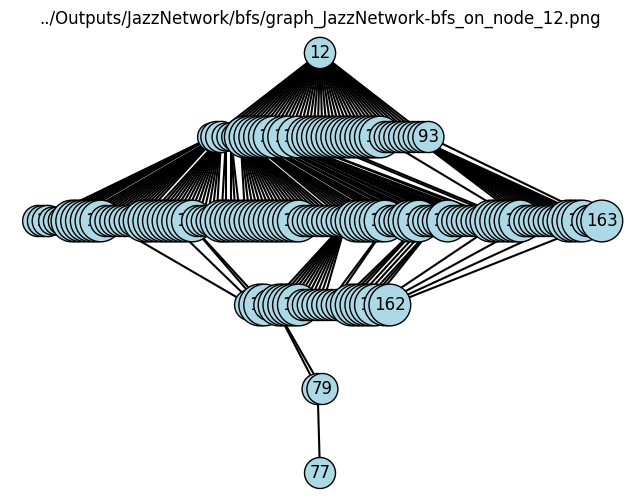

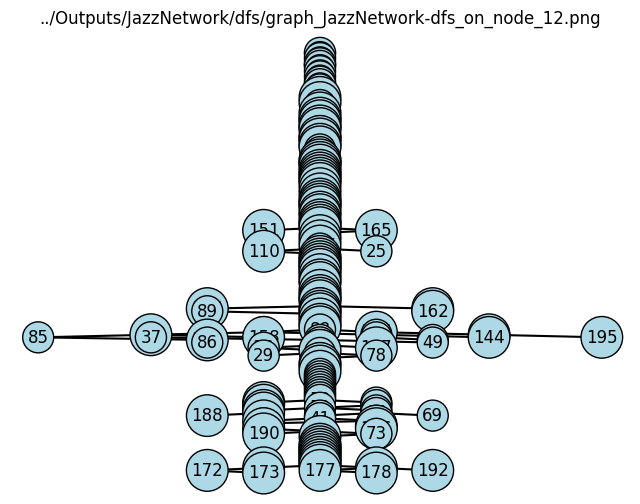

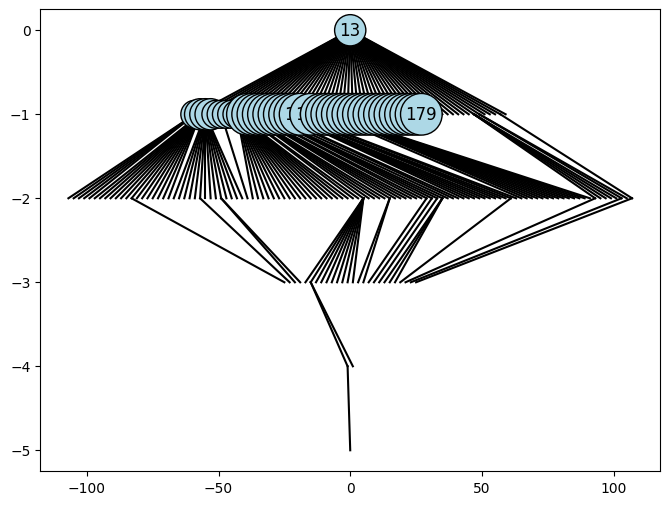

In [35]:
# draw a bfs tree for each node of a graph and save images in a folder:
for file_name, graph_name in zip(data_names, data_list):
    print(f"------ File: {file_name}\n")
    graph = parse_dot_file(graph_name)
    for node in graph.keys():
        print(f"Node: {node}")
        # create and draw the bfs
        bfs_result = create_bfs_tree(graph, node)
        dfs_result = create_dfs_tree(graph, node)
        #draw_layered_tree(bfs_result, f"BFS Layered Tree (Root: {node})")
        # save the image in an output folder
        image_name_bfs = f"../Outputs/{file_name}/bfs/graph_{file_name}-bfs_on_node_{node}.png"
        image_name_dfs = f"../Outputs/{file_name}/dfs/graph_{file_name}-dfs_on_node_{node}.png"
        save_drawing(bfs_result, image_name_bfs)
        save_drawing(dfs_result, image_name_dfs)
        print(f"Saved images of node: {node}")